In [1]:
from google.colab import files
uploaded = files.upload()


Saving Mall_Customers.csv to Mall_Customers (1).csv


In [3]:
import pandas as pd

df = pd.read_csv("Mall_Customers (1).csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              20 non-null     int64 
 1   Gender                  20 non-null     object
 2   Age                     20 non-null     int64 
 3   Annual Income (k$)      20 non-null     int64 
 4   Spending Score (1-100)  20 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 932.0+ bytes


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,20.00000,20.000000,20.000000,20.000000
mean,10.50000,33.650000,18.800000,50.950000
std,5.91608,15.114563,2.330575,34.149016
min,1.00000,19.000000,15.000000,3.000000
25%,5.75000,22.000000,17.000000,14.750000
50%,10.50000,30.500000,19.000000,53.000000
75%,15.25000,35.500000,20.000000,77.500000
max,20.00000,67.000000,23.000000,99.000000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

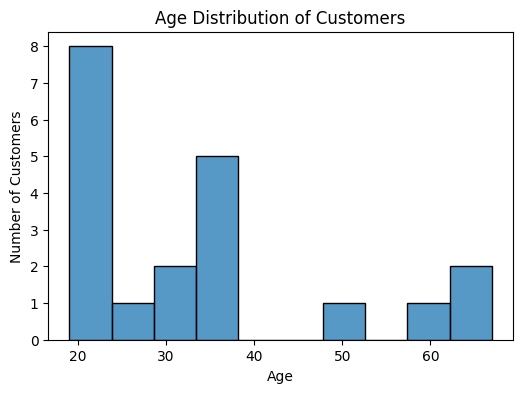

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=10)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

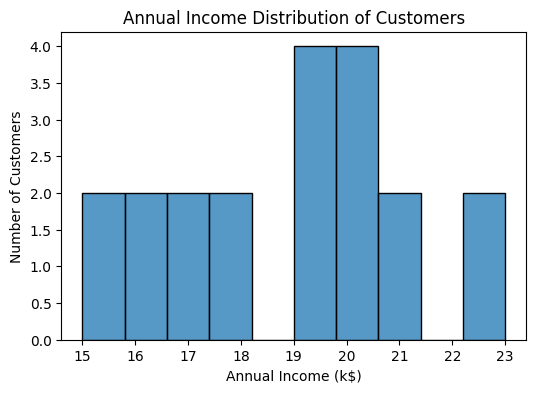

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=10)

plt.title("Annual Income Distribution of Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

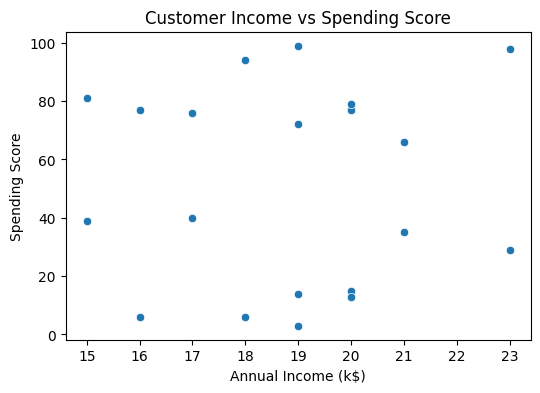

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)

plt.title("Customer Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

In [10]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.99444379, -1.67285672, -0.35902766],
       [-0.85868355, -1.67285672,  0.90282689],
       [-0.92656367, -1.23263127, -1.35048481],
       [-0.7229233 , -1.23263127,  0.78265027],
       [-0.17988232, -0.79240582, -0.32898351]])

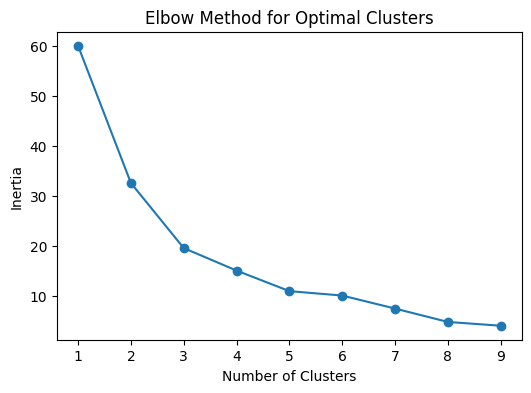

In [12]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


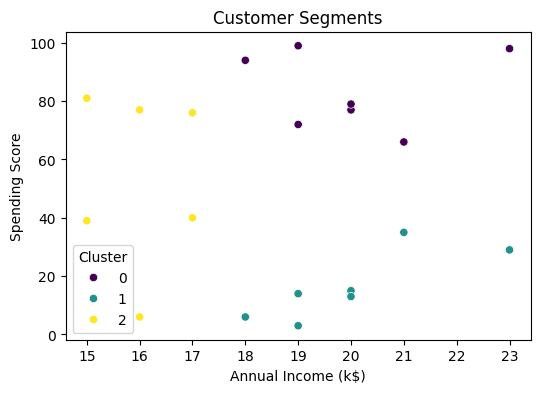

In [14]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

In [15]:
centers = kmeans.cluster_centers_

centers

array([[-0.45140281,  0.52827054,  0.98008329],
       [ 1.09044568,  0.52827054, -1.03716719],
       [-0.74555001, -1.23263127,  0.06659788]])

In [16]:
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

centers_original

array([[27.        , 20.        , 83.57142857],
       [49.71428571, 20.        , 16.42857143],
       [22.66666667, 16.        , 53.16666667]])

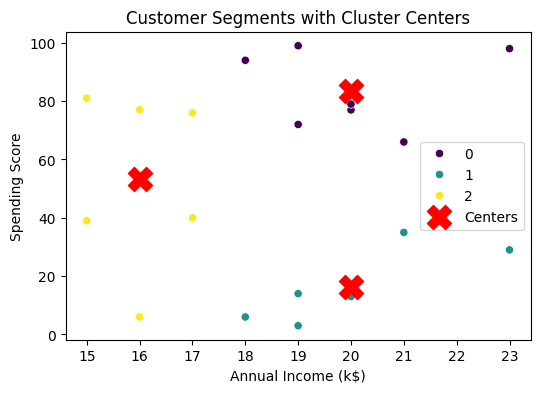

In [17]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.scatter(
    centers_original[:,1],
    centers_original[:,2],
    s=300,
    c='red',
    marker='X',
    label='Centers'
)

plt.title("Customer Segments with Cluster Centers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.legend()

plt.show()